<u><b>ML Project 2</b></u>

**1. Loading and Inspecting Data**

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [109]:
df = pd.read_csv("../data/raw/diabetes_dataset.csv")

df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [110]:
df.shape

(100000, 31)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [112]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [113]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [50]:
print("Class distribution:\n", df['diagnosed_diabetes'].value_counts())

Class distribution:
 diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64


In [51]:
print("Class distribution:\n", df['diabetes_stage'].value_counts())

Class distribution:
 diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64


In [52]:
print("Class distribution:\n", df['diabetes_risk_score'].value_counts())

Class distribution:
 diabetes_risk_score
26.6    550
27.8    548
26.7    539
27.2    535
28.4    528
       ... 
7.7       1
5.9       1
61.3      1
6.2       1
62.9      1
Name: count, Length: 569, dtype: int64


**2. Data Preprocessing**

In [114]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [115]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [116]:
df.select_dtypes(include=['object']).columns

Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'diabetes_stage'],
      dtype='object')

In [117]:
#label encoding for target feature
le = LabelEncoder()
df['diabetes_stage'] = le.fit_transform(df['diabetes_stage'])

# one-hot encode categorical features
df = pd.get_dummies(df, columns=[
    'gender',
    'ethnicity',
    'education_level',
    'income_level',
    'employment_status',
    'smoking_status'
])

In [119]:
scaler = StandardScaler()

features = df.drop(columns=['diagnosed_diabetes','diabetes_stage','diabetes_risk_score'])

scaled_features = scaler.fit_transform(features)

In [120]:
df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

In [121]:
X_binary = df.drop(columns=['diagnosed_diabetes'])
y_binary = df['diagnosed_diabetes']

In [122]:
X_multi = df.drop(columns=['diabetes_stage'])
y_multi = df['diabetes_stage']

In [123]:
X_reg = df.drop(columns=['diabetes_risk_score'])
y_reg = df['diabetes_risk_score']

**3. Exploratory Data Analysis**

*Analyzing Distribution of Target Variables*

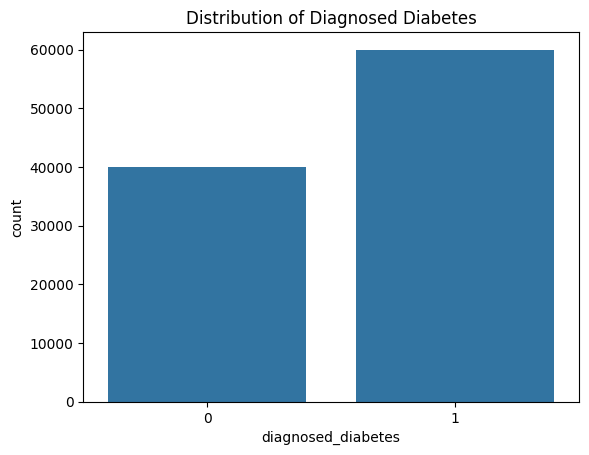

In [63]:
sns.countplot(x='diagnosed_diabetes', data=df)
plt.title("Distribution of Diagnosed Diabetes")
plt.show()

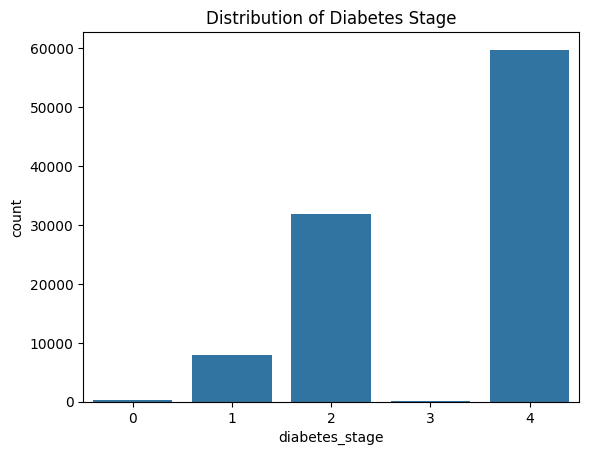

In [124]:
sns.countplot(x='diabetes_stage', data=df)
plt.title("Distribution of Diabetes Stage")
plt.show()

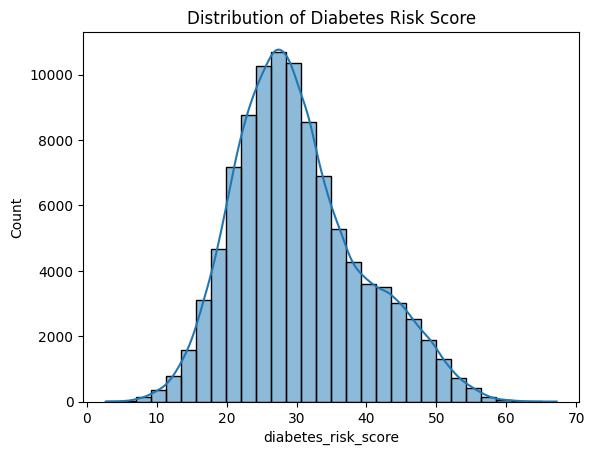

In [125]:
sns.histplot(df['diabetes_risk_score'], bins=30, kde=True)
plt.title("Distribution of Diabetes Risk Score")
plt.show()

*Analyzing Distribution of Features*

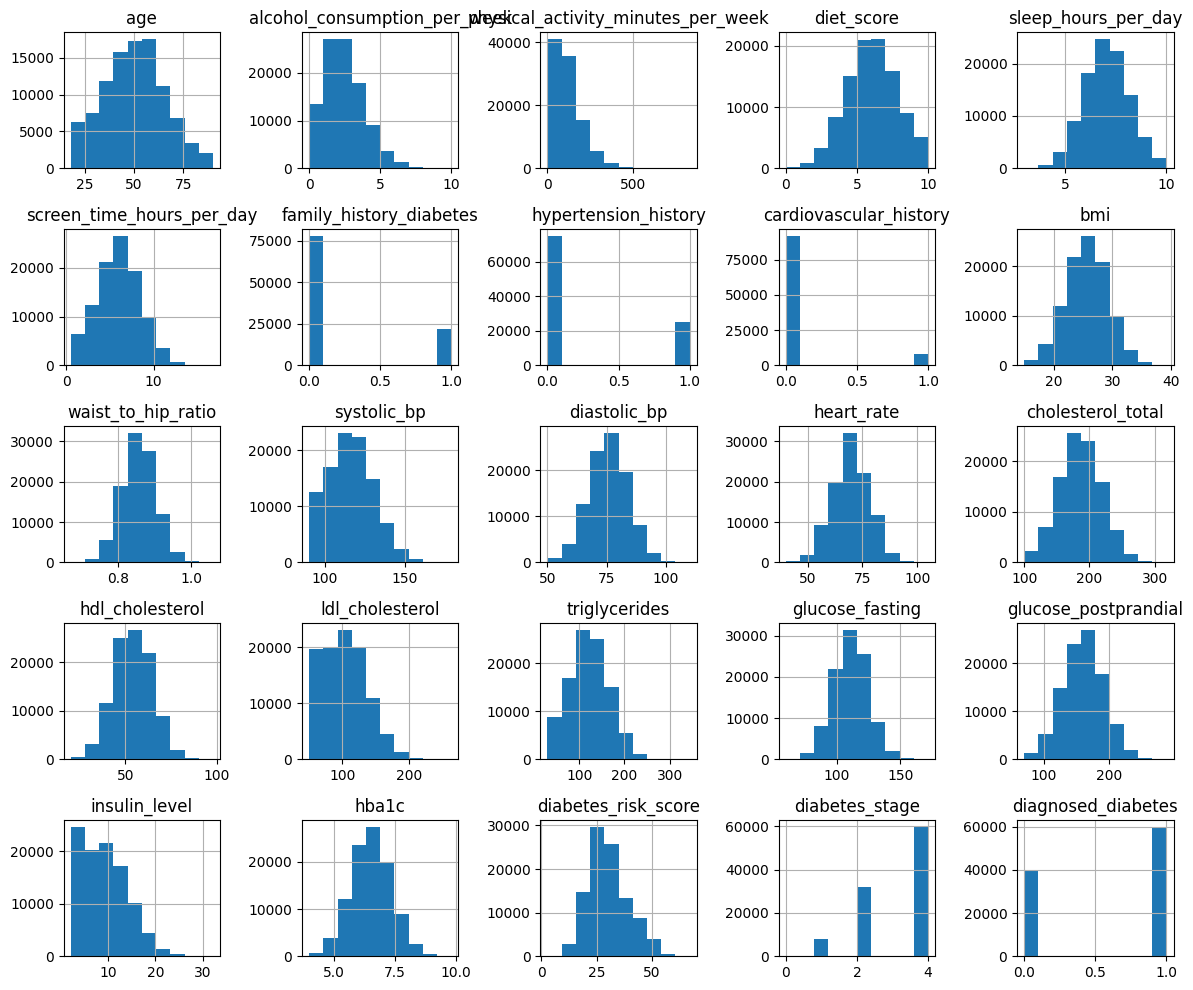

In [66]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

*Analyzing Correlation*

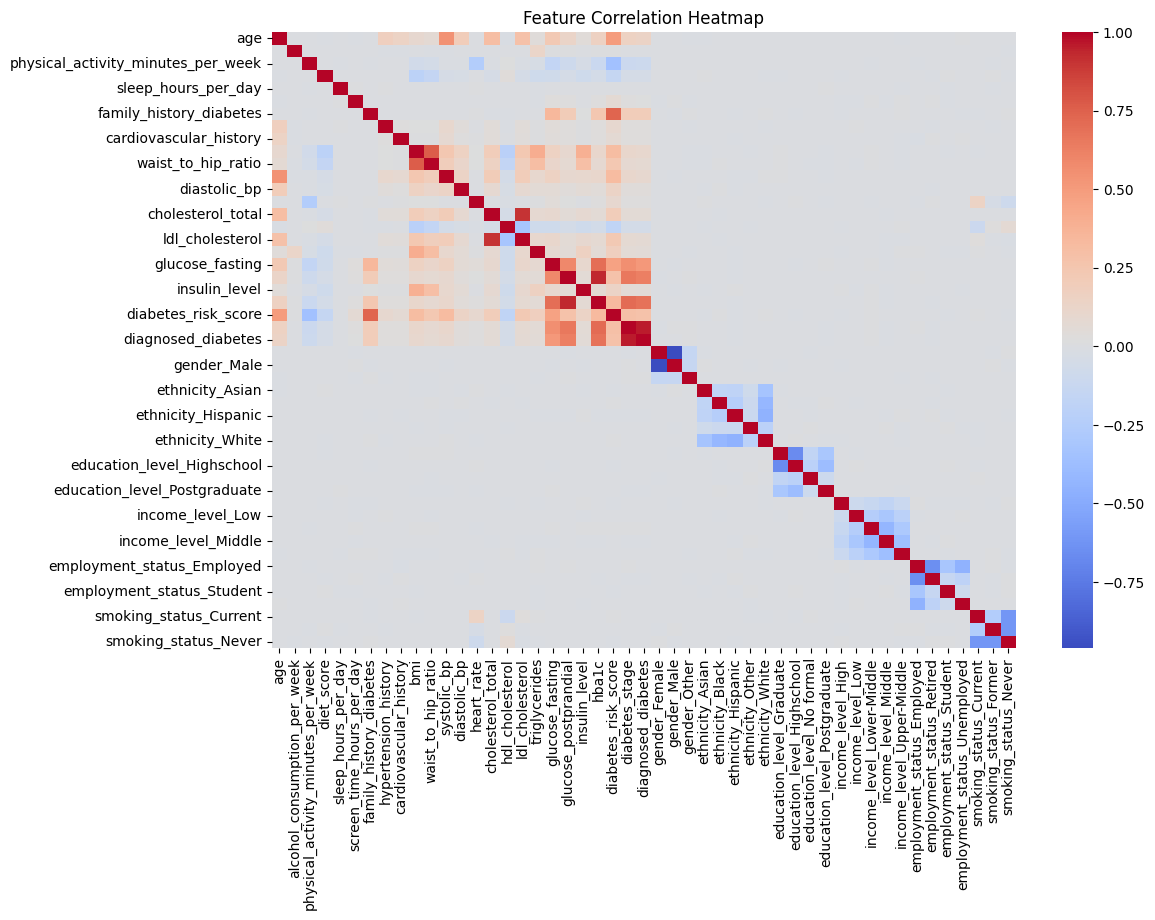

In [126]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

*Analyzing Correlation of Diagnosed Diabetes With Other Features*

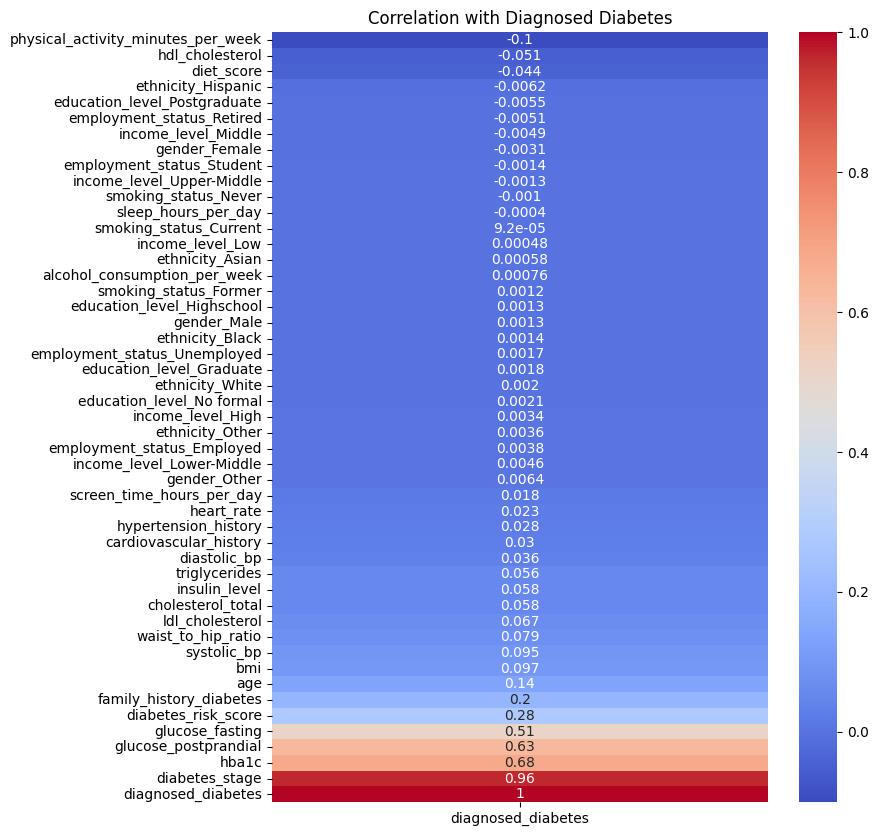

In [128]:
corr_target = df.corr()['diagnosed_diabetes'].sort_values()

plt.figure(figsize=(8,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Diagnosed Diabetes")
plt.show()

*Analyzing Correlation of Diabetes Stage With Other Features*

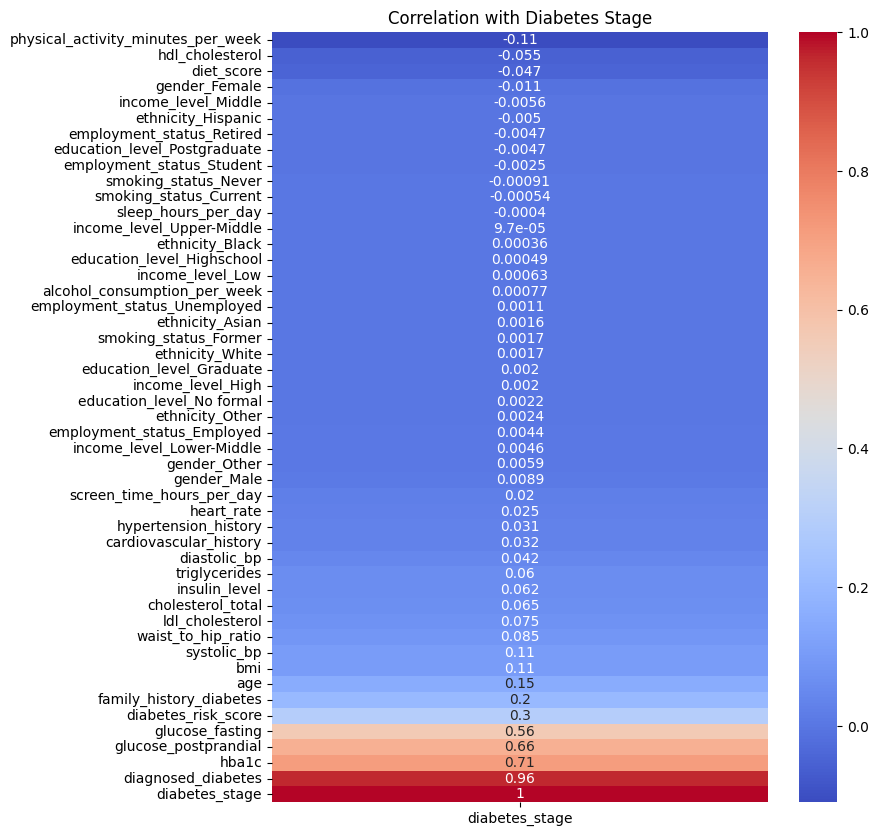

In [129]:
corr_target = df.corr()['diabetes_stage'].sort_values()

plt.figure(figsize=(8,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Diabetes Stage")
plt.show()

*Analyzing Correlation of Diabetes Risk Score With Other Features*

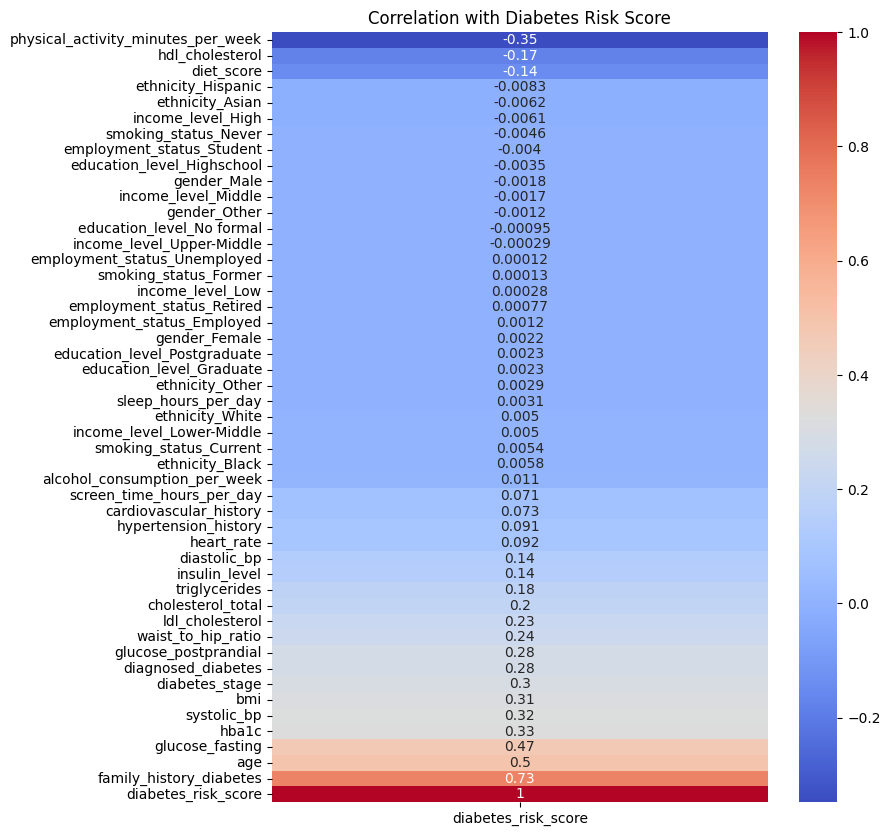

In [130]:
corr_target = df.corr()['diabetes_risk_score'].sort_values()

plt.figure(figsize=(8,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Diabetes Risk Score")
plt.show()

In [132]:
top_features = df.corr()['diagnosed_diabetes'].abs().sort_values(ascending=False)[1:6]

top_features

diabetes_stage          0.961453
hba1c                   0.679397
glucose_postprandial    0.629832
glucose_fasting         0.510919
diabetes_risk_score     0.277300
Name: diagnosed_diabetes, dtype: float64

*Checking Relation of Diagnosed Diabetes With Top Correlated Features*

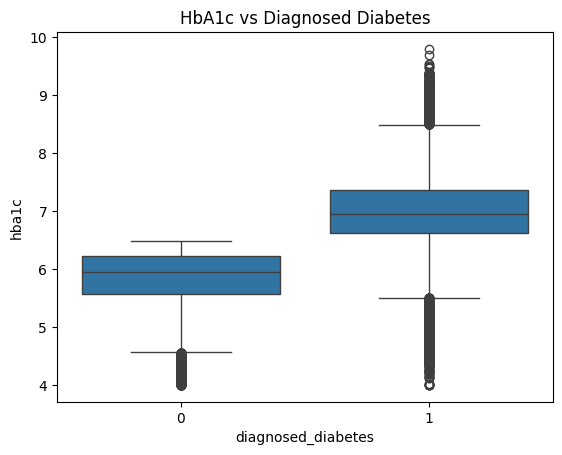

In [133]:
sns.boxplot(x='diagnosed_diabetes', y='hba1c', data=df)
plt.title("HbA1c vs Diagnosed Diabetes")
plt.show()

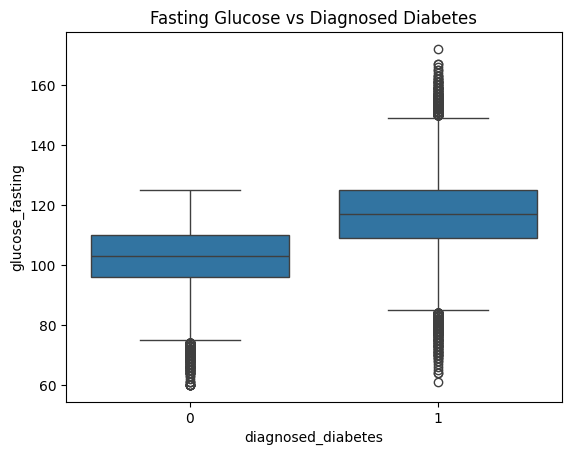

In [134]:
sns.boxplot(x='diagnosed_diabetes', y='glucose_fasting', data=df)
plt.title("Fasting Glucose vs Diagnosed Diabetes")
plt.show()

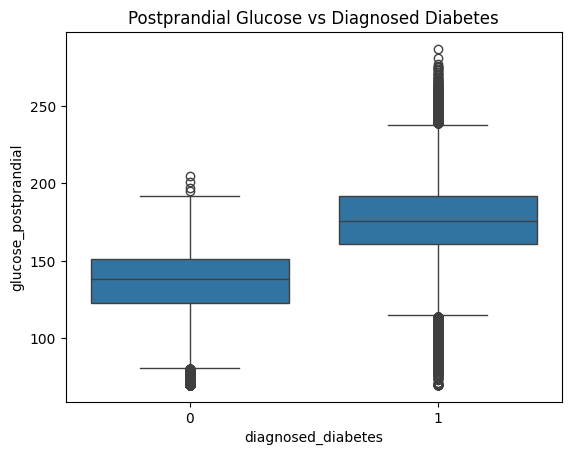

In [135]:
sns.boxplot(x='diagnosed_diabetes', y='glucose_postprandial', data=df)
plt.title("Postprandial Glucose vs Diagnosed Diabetes")
plt.show()

In [136]:
top_features = df.corr()['diabetes_stage'].abs().sort_values(ascending=False)[1:6]

top_features

diagnosed_diabetes      0.961453
hba1c                   0.710258
glucose_postprandial    0.655525
glucose_fasting         0.558491
diabetes_risk_score     0.295138
Name: diabetes_stage, dtype: float64

*Checking Relation of Diabetes Stage With Top Correlated Features*

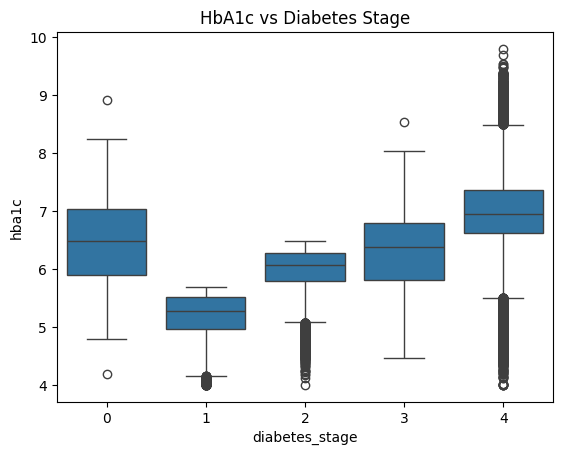

In [137]:
sns.boxplot(x='diabetes_stage', y='hba1c', data=df)
plt.title("HbA1c vs Diabetes Stage")
plt.show()

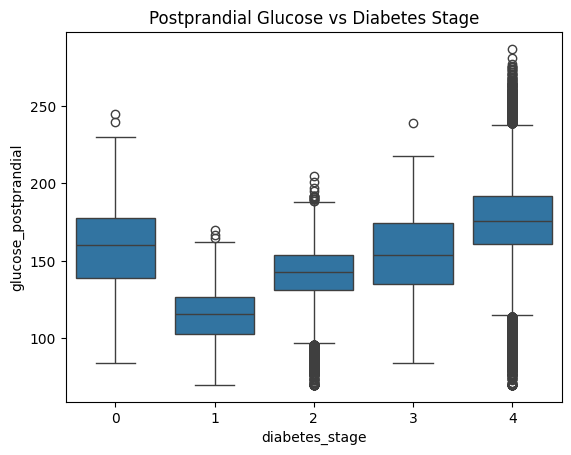

In [138]:
sns.boxplot(x='diabetes_stage', y='glucose_postprandial', data=df)
plt.title("Postprandial Glucose vs Diabetes Stage")
plt.show()

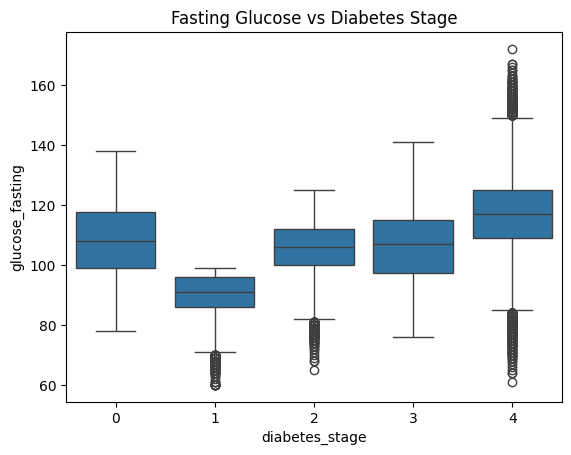

In [139]:
sns.boxplot(x='diabetes_stage', y='glucose_fasting', data=df)
plt.title("Fasting Glucose vs Diabetes Stage")
plt.show()

In [140]:
top_features = df.corr()['diabetes_risk_score'].abs().sort_values(ascending=False)[1:6]

top_features

family_history_diabetes               0.733085
age                                   0.495924
glucose_fasting                       0.469938
physical_activity_minutes_per_week    0.348121
hba1c                                 0.329947
Name: diabetes_risk_score, dtype: float64

*Checking Relation of Diabetes Risk Score With Top Correlated Features*

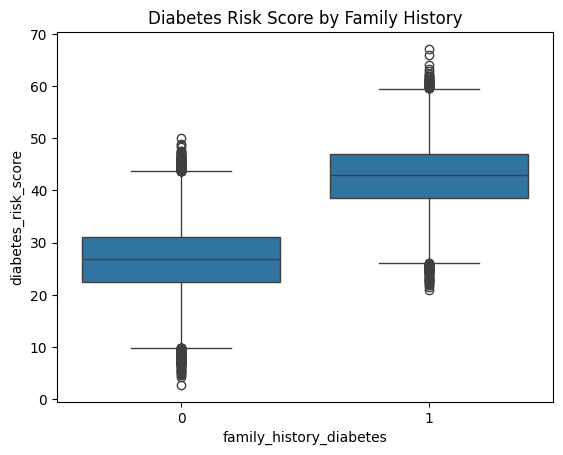

In [141]:
sns.boxplot(x='family_history_diabetes', y='diabetes_risk_score', data=df)
plt.title("Diabetes Risk Score by Family History")
plt.show()

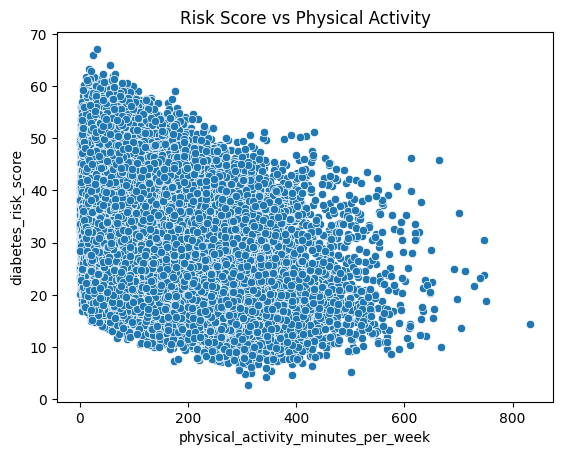

In [142]:
sns.scatterplot(x='physical_activity_minutes_per_week', y='diabetes_risk_score', data=df)
plt.title("Risk Score vs Physical Activity")
plt.show()

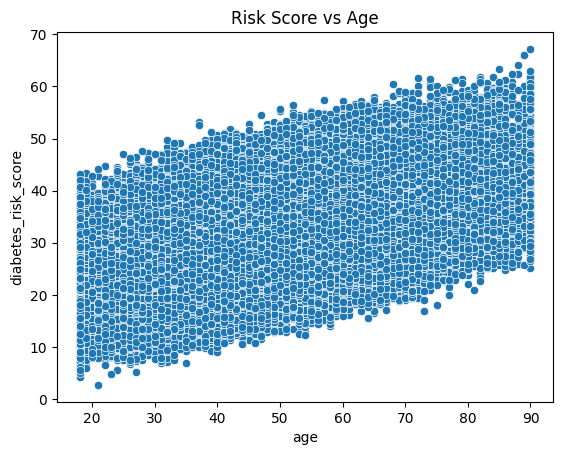

In [144]:
sns.scatterplot(x='age', y='diabetes_risk_score', data=df)
plt.title("Risk Score vs Age")
plt.show()

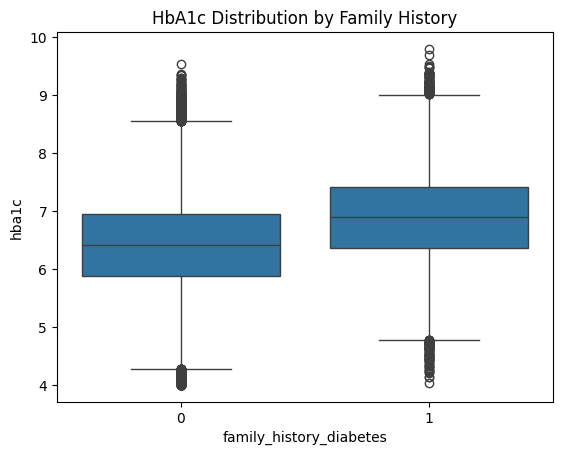

In [145]:
sns.boxplot(x='family_history_diabetes', y='hba1c', data=df)
plt.title("HbA1c Distribution by Family History")
plt.show()

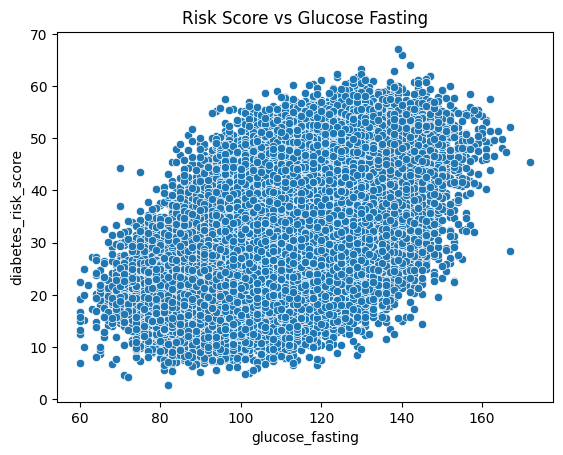

In [146]:
sns.scatterplot(x='glucose_fasting', y='diabetes_risk_score', data=df)
plt.title("Risk Score vs Glucose Fasting")
plt.show()

**4. Data Splitting**

In [147]:
X_binary = df.drop(columns=['diagnosed_diabetes','diabetes_stage','diabetes_risk_score'])
y_binary = df['diagnosed_diabetes']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_binary, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

In [148]:
X_multi = df.drop(columns=['diabetes_stage','diagnosed_diabetes','diabetes_risk_score'])
y_multi = df['diabetes_stage']

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

In [149]:
X_reg = df.drop(columns=['diabetes_risk_score','diagnosed_diabetes','diabetes_stage'])
y_reg = df['diabetes_risk_score']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

**5. Baseline Model Training and Evaluation**

**Binary Classification For Diagnosed Diabetes**

*Logistic Regression*

In [150]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(Xb_train, yb_train)

yb_pred = log_model.predict(Xb_test)
yb_prob = log_model.predict_proba(Xb_test)[:,1]

In [151]:
print("Accuracy:", accuracy_score(yb_test, yb_pred))
print("Precision:", precision_score(yb_test, yb_pred))
print("Recall:", recall_score(yb_test, yb_pred))
print("F1:", f1_score(yb_test, yb_pred))

print(classification_report(yb_test, yb_pred))

Accuracy: 0.84715
Precision: 0.8607503025413473
Recall: 0.8890833333333333
F1: 0.8746874359499898
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      8000
           1       0.86      0.89      0.87     12000

    accuracy                           0.85     20000
   macro avg       0.84      0.84      0.84     20000
weighted avg       0.85      0.85      0.85     20000



In [152]:
roc_auc = roc_auc_score(yb_test, yb_prob)
print("ROC AUC:", roc_auc)

ROC AUC: 0.9234159791666667


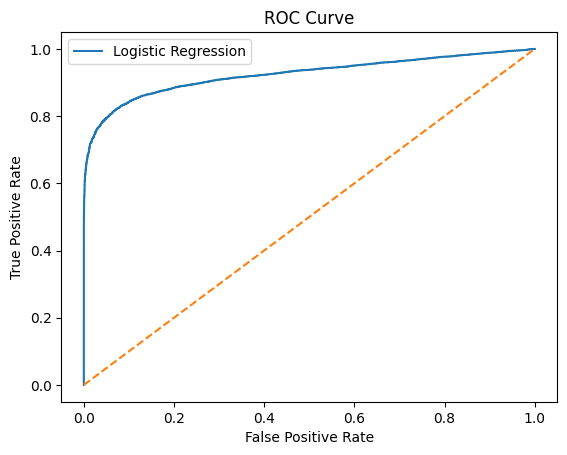

In [153]:
fpr, tpr, _ = roc_curve(yb_test, yb_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


*Decision Tree*

In [154]:
dt_model = DecisionTreeClassifier()

dt_model.fit(Xb_train, yb_train)

dt_pred = dt_model.predict(Xb_test)

print(classification_report(yb_test, dt_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      8000
           1       0.87      0.89      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



*KNN*

In [155]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(Xb_train, yb_train)

knn_pred = knn_model.predict(Xb_test)

print(classification_report(yb_test, knn_pred))

              precision    recall  f1-score   support

           0       0.75      0.78      0.77      8000
           1       0.85      0.82      0.84     12000

    accuracy                           0.81     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.81      0.81      0.81     20000



**Multi Classification For Diabetes Stage**

*Logistic Regression*

In [162]:
log_multi = LogisticRegression(max_iter=1000)

log_multi.fit(Xm_train, ym_train)

ym_pred_log = log_multi.predict(Xm_test)

print("Accuracy:", accuracy_score(ym_test, ym_pred_log))
print("Macro F1:", f1_score(ym_test, ym_pred_log, average='macro'))

Accuracy: 0.7685
Macro F1: 0.415493516710238


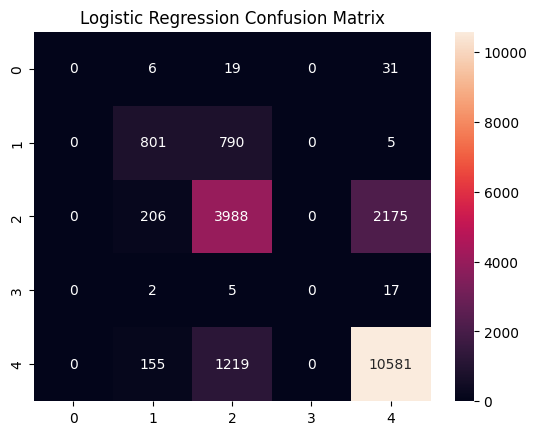

In [163]:
cm = confusion_matrix(ym_test, ym_pred_log)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

*Decision Tree Classifier*

In [164]:
dt_multi = DecisionTreeClassifier(random_state=42)

dt_multi.fit(Xm_train, ym_train)

ym_pred_dt = dt_multi.predict(Xm_test)

print("Accuracy:", accuracy_score(ym_test, ym_pred_dt))
print("Macro F1:", f1_score(ym_test, ym_pred_dt, average='macro'))

Accuracy: 0.8548
Macro F1: 0.5144945868055769


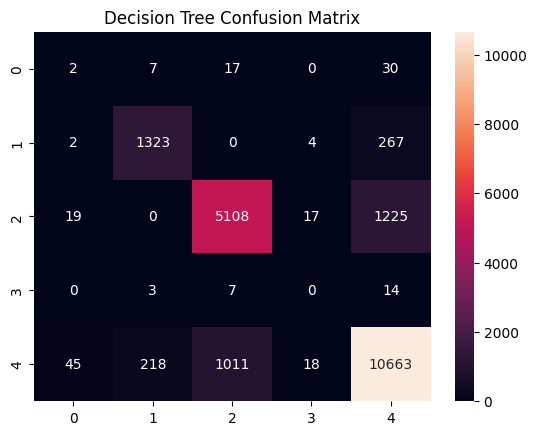

In [165]:
cm = confusion_matrix(ym_test, ym_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

*KNN*

In [166]:
knn_multi = KNeighborsClassifier(n_neighbors=5)

knn_multi.fit(Xm_train, ym_train)

ym_pred_knn = knn_multi.predict(Xm_test)

print("Accuracy:", accuracy_score(ym_test, ym_pred_knn))
print("Macro F1:", f1_score(ym_test, ym_pred_knn, average='macro'))

Accuracy: 0.7594
Macro F1: 0.42174796328307984


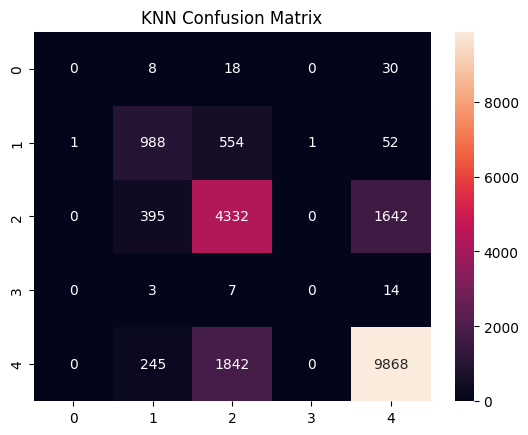

In [167]:
cm = confusion_matrix(ym_test, ym_pred_knn)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.show()

In [169]:
results = {
    "Model": ["Logistic Regression","Decision Tree","KNN"],
    "Accuracy": [
        accuracy_score(ym_test, ym_pred_log),
        accuracy_score(ym_test, ym_pred_dt),
        accuracy_score(ym_test, ym_pred_knn)
    ],
    "Macro F1":[
        f1_score(ym_test, ym_pred_log, average='macro'),
        f1_score(ym_test, ym_pred_dt, average='macro'),
        f1_score(ym_test, ym_pred_knn, average='macro')
    ]
}

pd.DataFrame(results)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.7685,0.415494
1,Decision Tree,0.8548,0.514495
2,KNN,0.7594,0.421748


**Regression For Diabetes Risk Score**

*Linear Regression*

In [159]:
lin_model = LinearRegression()

lin_model.fit(Xr_train, yr_train)

yr_pred = lin_model.predict(Xr_test)

In [160]:
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = mse ** 0.5
r2 = r2_score(yr_test, yr_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.4390649755327375
MSE: 0.5543262722556869
RMSE: 0.7445309075221034
R2: 0.9932831185187904


*Decision Tree Regressor*

In [161]:
dt_reg = DecisionTreeRegressor()

dt_reg.fit(Xr_train, yr_train)

yr_pred_tree = dt_reg.predict(Xr_test)

print("R2:", r2_score(yr_test, yr_pred_tree))

R2: 0.9692809084935168


**6. HyperParameter Tuning**

*For Binary Classification*

In [170]:
from sklearn.model_selection import GridSearchCV

In [171]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3,5,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

grid_binary = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_binary.fit(Xb_train, yb_train)

best_binary_model = grid_binary.best_estimator_

print("Best Params:", grid_binary.best_params_)

Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [172]:
yb_pred = best_binary_model.predict(Xb_test)

print("Accuracy:", accuracy_score(yb_test, yb_pred))
print(classification_report(yb_test, yb_pred))

Accuracy: 0.91985
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



*For Multi Classification*

In [173]:
param_grid = {
    'max_depth': [3,5,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

grid_multi = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_multi.fit(Xm_train, ym_train)

best_multi_model = grid_multi.best_estimator_

print("Best Params:", grid_multi.best_params_)

Best Params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


Accuracy: 0.9185
Macro F1: 0.5505717176328273
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.85      1.00      0.92      1596
           2       0.83      1.00      0.91      6369
           3       0.00      0.00      0.00        24
           4       1.00      0.87      0.93     11955

    accuracy                           0.92     20000
   macro avg       0.53      0.57      0.55     20000
weighted avg       0.93      0.92      0.92     20000



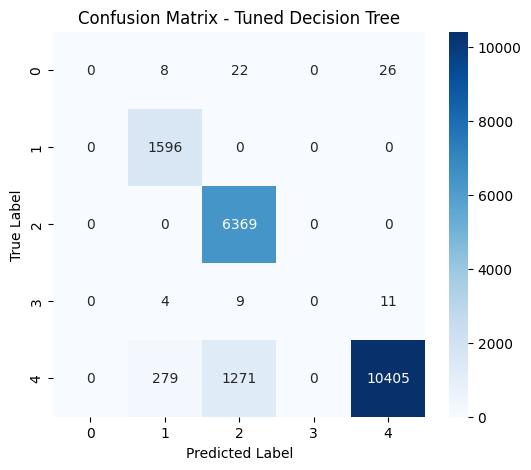

In [177]:
ym_pred = best_multi_model.predict(Xm_test)
print("Accuracy:", accuracy_score(ym_test, ym_pred))
print("Macro F1:", f1_score(ym_test, ym_pred, average='macro'))

print(classification_report(ym_test, ym_pred))
cm = confusion_matrix(ym_test, ym_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned Decision Tree")

plt.show()

*For Regression*

In [178]:
from sklearn.linear_model import LinearRegression

param_grid = {
    'fit_intercept': [True, False]
}

grid_reg = GridSearchCV(
    LinearRegression(),
    param_grid,
    cv=5,
    scoring='r2'
)

grid_reg.fit(Xr_train, yr_train)

best_reg_model = grid_reg.best_estimator_

print("Best Params:", grid_reg.best_params_)

Best Params: {'fit_intercept': True}


In [179]:
yr_pred = best_reg_model.predict(Xr_test)
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.4390649755327375
MSE: 0.5543262722556869
RMSE: 0.7445309075221034
R2 Score: 0.9932831185187904


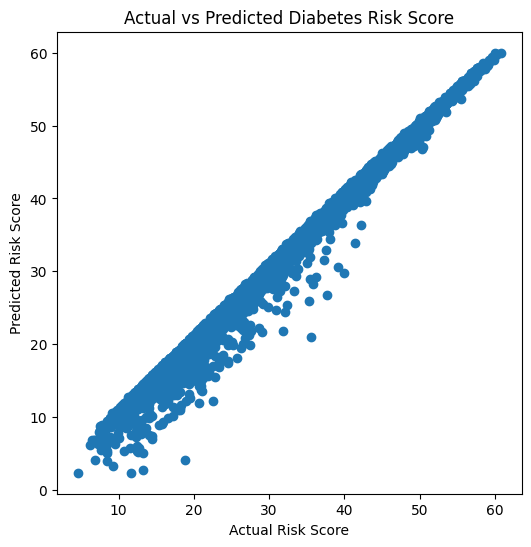

In [180]:
plt.figure(figsize=(6,6))
plt.scatter(yr_test, yr_pred)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Actual vs Predicted Diabetes Risk Score")

plt.show()

Hyperparameter tuning was performed on the best-performing models from the baseline evaluation using GridSearchCV with 5 fold cross-validation. Decision Tree models were tuned for binary and multiclass classification while Linear Regression was tuned for the regression task.

**Model Export**

In [181]:
import joblib

joblib.dump(best_binary_model, "../models/binary_model.joblib")

joblib.dump(best_multi_model, "../models/multiclass_model.joblib")

joblib.dump(best_reg_model, "../models/regression_model.joblib")

['../models/regression_model.joblib']

The final tuned models were exported to the models directory using joblib.dump() for future reuse and deployment without retraining.

**Stored Cleaned Dataset**


In [182]:
df.to_csv("../data/processed/diabetes_processed.csv", index=False)

Note: For simplicity, preprocessing and evaluation steps are implemented directly in the notebook. 
In a production pipeline, these would typically be placed inside the src/ directory as reusable modules.